In [1]:
%reload_ext autoreload
%autoreload 2

# Imports

In [2]:
from kret_notebook import *  # NOTE import first

# from kret_lgbm._core.lgbm_nb_imports import *
# from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *

# from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *

# from kret_sklearn._core.sklearn_nb_imports import *
# from kret_torch_utils._core.torch_nb_imports import *
# from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 2.6595 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0006 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0000 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_type_hints._core.types_nb_imports] Imported kret_type_hints._core.types_nb_imports in 0.0008 seconds
[kret_utils._core.utils_nb_imports] Imported kret_utils._core.utils_nb_imports in 0.0072 seconds


In [3]:
from nba_timeout_impact.nb_imports import *

# TV / mandatory timeout study

Two questions:

1. **Visual evidence** that mandatory timeouts in cdnnba (post-2017) already exist as ordinary `subType="full"` rows, clustering at the rulebook trigger marks.
2. **Reclassification** of each timeout row's role (slot_K_mandatory / slot_K_absorbed / discretionary / challenge), tested on the v3 labeled era (1998-2016) against ground-truth `Official` / `Official TV` subTypes.

# Load data

In [4]:
memo_v3 = NBAMemoDF.load_all()  # nbastatsv3 + nbastats v2 (~1s)
memo_cdn = CDNNBAMemoPL.load_all()  # cdnnba post-2017 (~3s)

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 78 cols, 1 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).


# Part 1 — Density of cdnnba timeouts by clock bin

The cdnnba memo has a parameterized `sr_bin(width)` column. Plot the
density of `full` and `challenge` timeouts at 15s / 30s / 60s resolutions
to see where they cluster relative to the rulebook trigger marks (7:00
and 3:00 = sr=420 and sr=180).

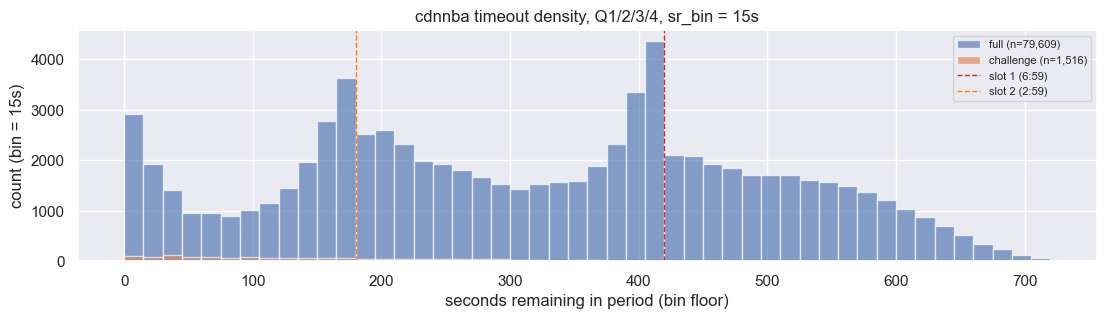

In [5]:
fig_vanilla, axes = TimeoutInjectionPlots.plot_timeout_vanilla(memo_cdn.cdnnba)
fig_vanilla

# Part 3 - cdnnba classification 

Examine the cdnnba data and predictions


## Plots

In [6]:
seasons = None  # (2020, 2025)
cdn_pl = TVTimeoutValidation._prep_cdnnba(memo_cdn, seasons=seasons)
classified = TVTimeoutValidation.classify_timeouts(cdn_pl, source="cdnnba", seasons=seasons)

In [7]:
# # Validation
# r = TVTimeoutValidation.validate_against_cdnnba(memo_cdn, seasons=seasons)
# print(r.summary())  # F1=1.000 (predicting from the same signal we score on)

# # Confusion matrix
# TVTimeoutValidation.confusion_matrix_cdnnba(memo_cdn, seasons=seasons)

In [8]:
figs = TimeoutInjectionPlots.diagnose_cdnnba(classified, full_pbp_pl=memo_cdn)

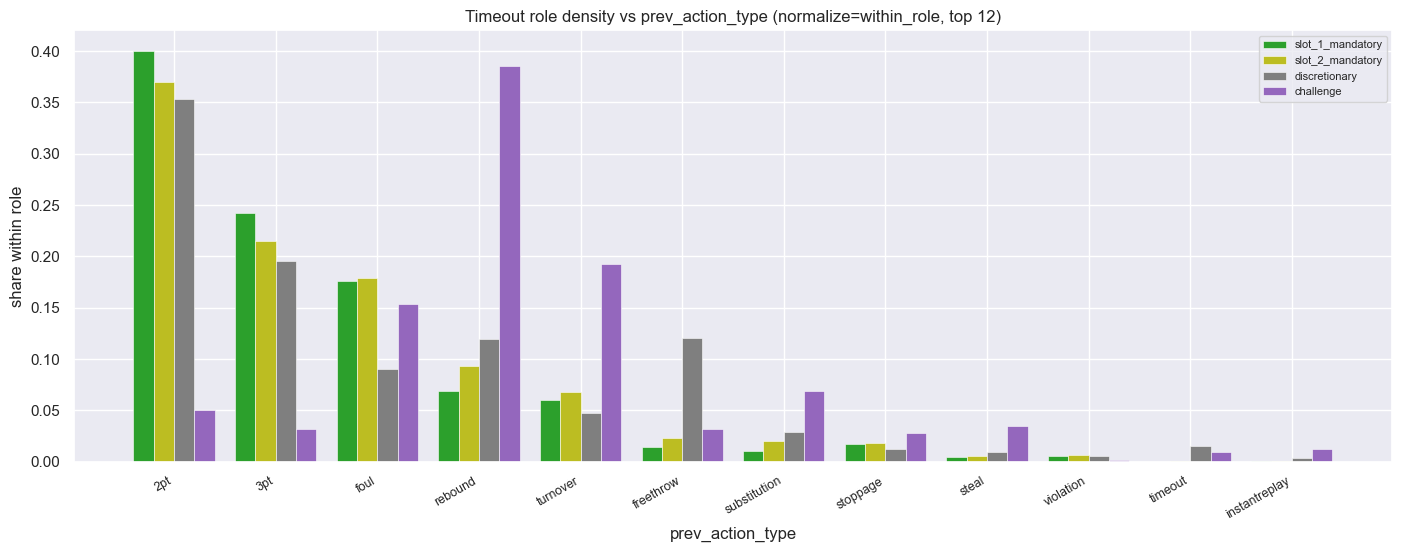

In [9]:
figs["role_vs_prev_action_type"]

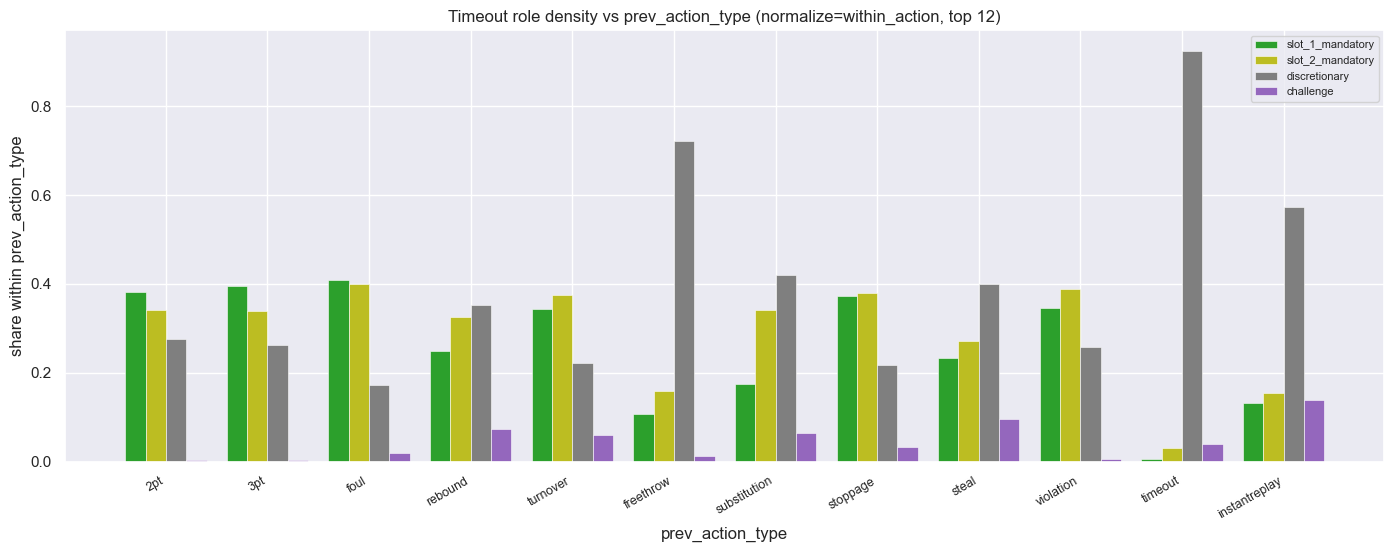

In [10]:
fig, ax, mat = TimeoutInjectionPlots.plot_role_vs_prev_action_type(
    classified, memo_cdn, normalize="within_action"  # "given X happened, what fraction of TOs are mandatory?"
)
fig

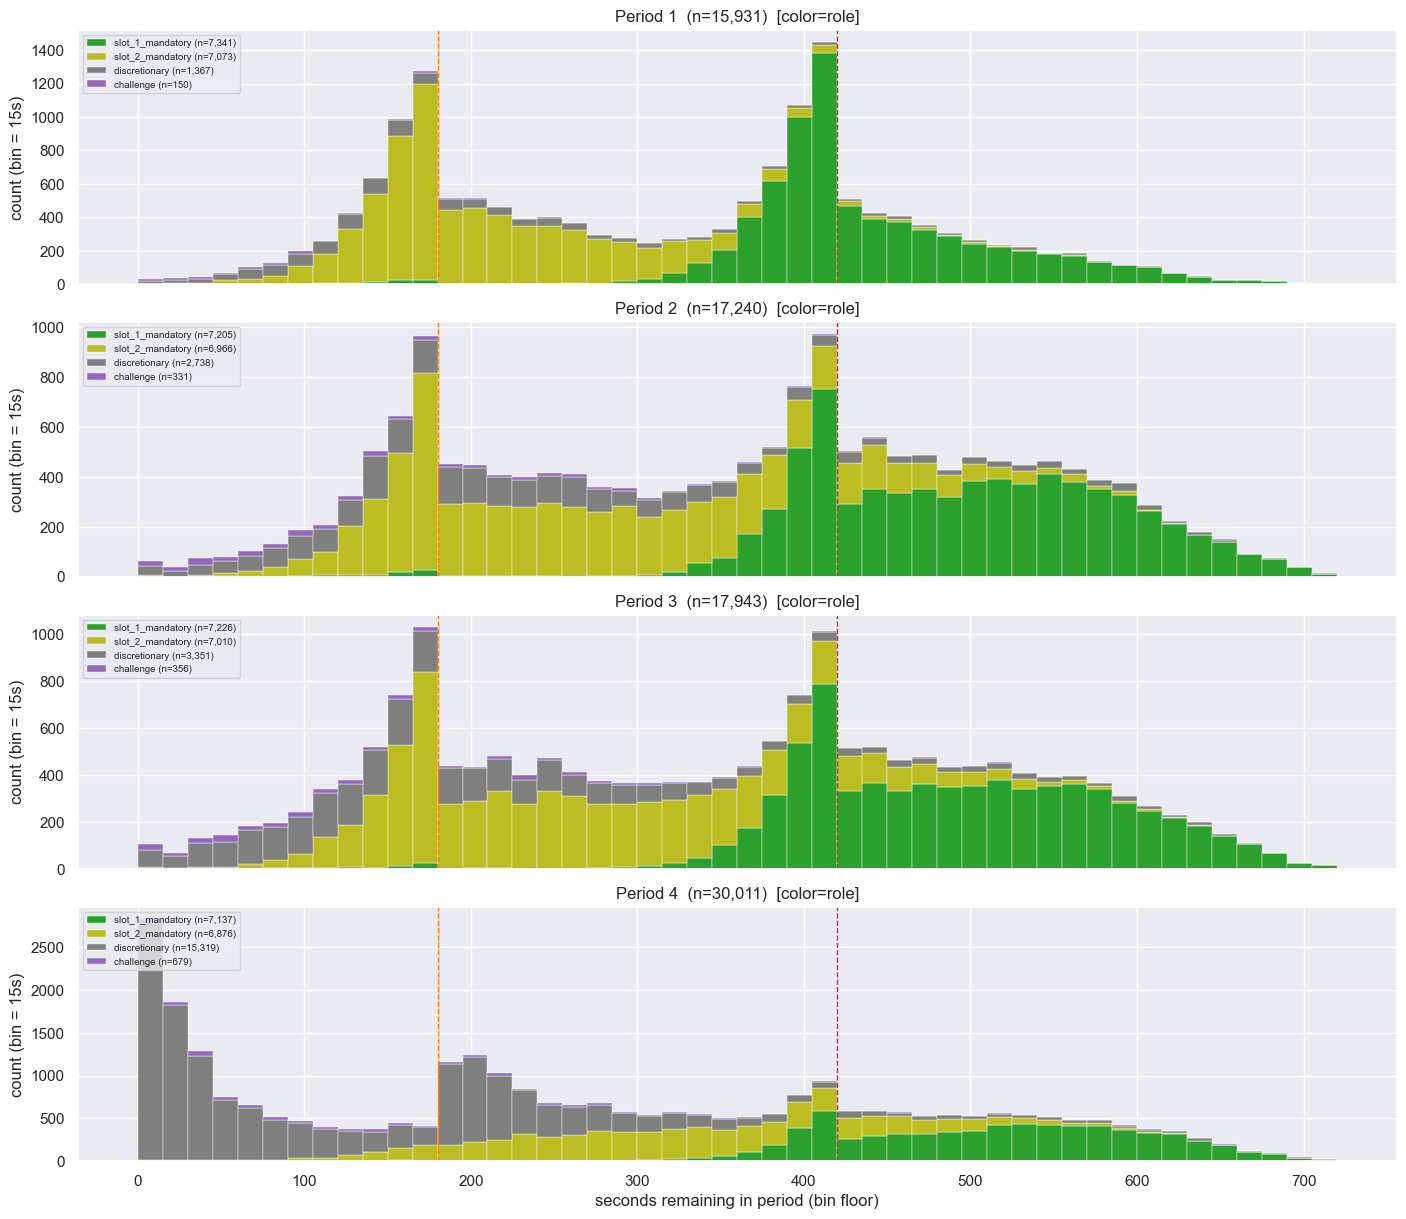

In [11]:
figs["role_vs_sr"]

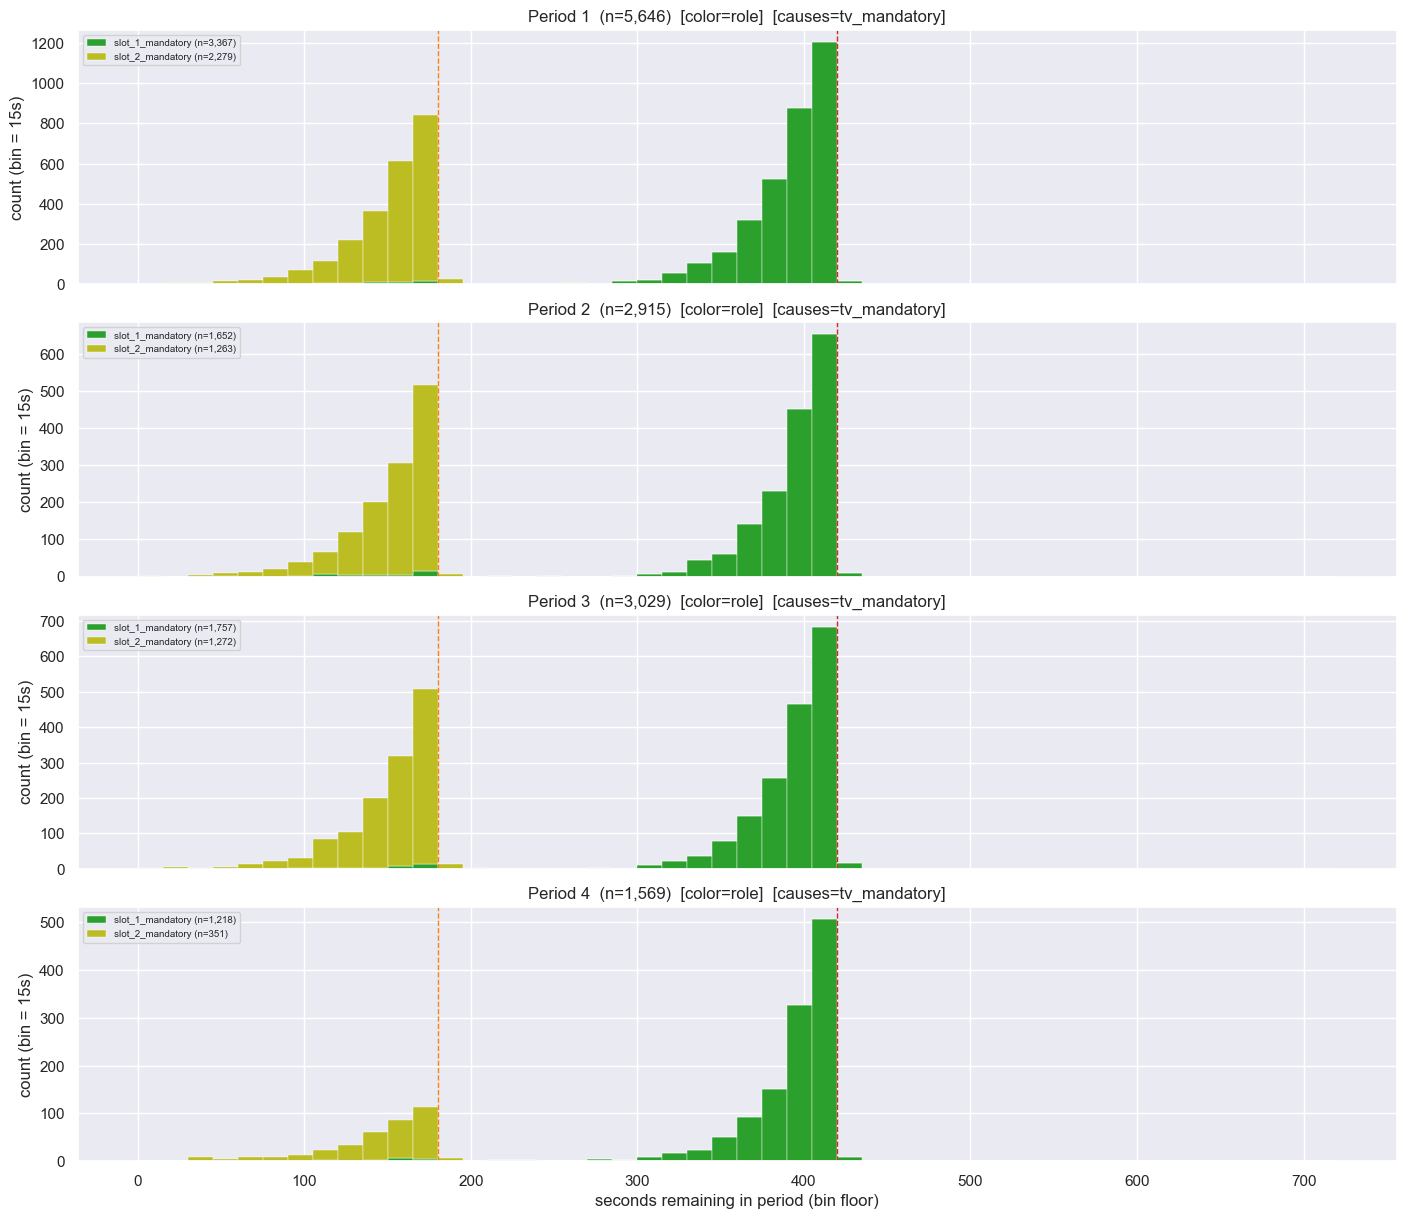

In [12]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("tv_mandatory",))
fig

In [13]:
classified["timeout_cause"].value_counts()

timeout_cause,count
str,u32
"""coach_absorb""",6805
"""challenge""",1555
"""mistagged_discretionary""",36918
"""tv_mandatory""",13172
"""""",4086589
"""coach_discretionary""",23747


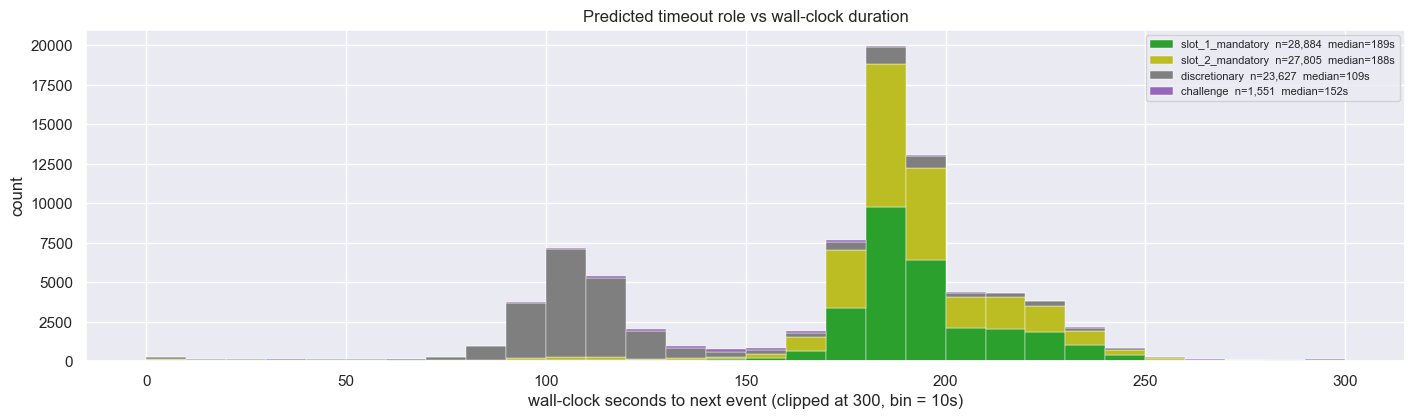

In [14]:
figs["role_vs_duration"]

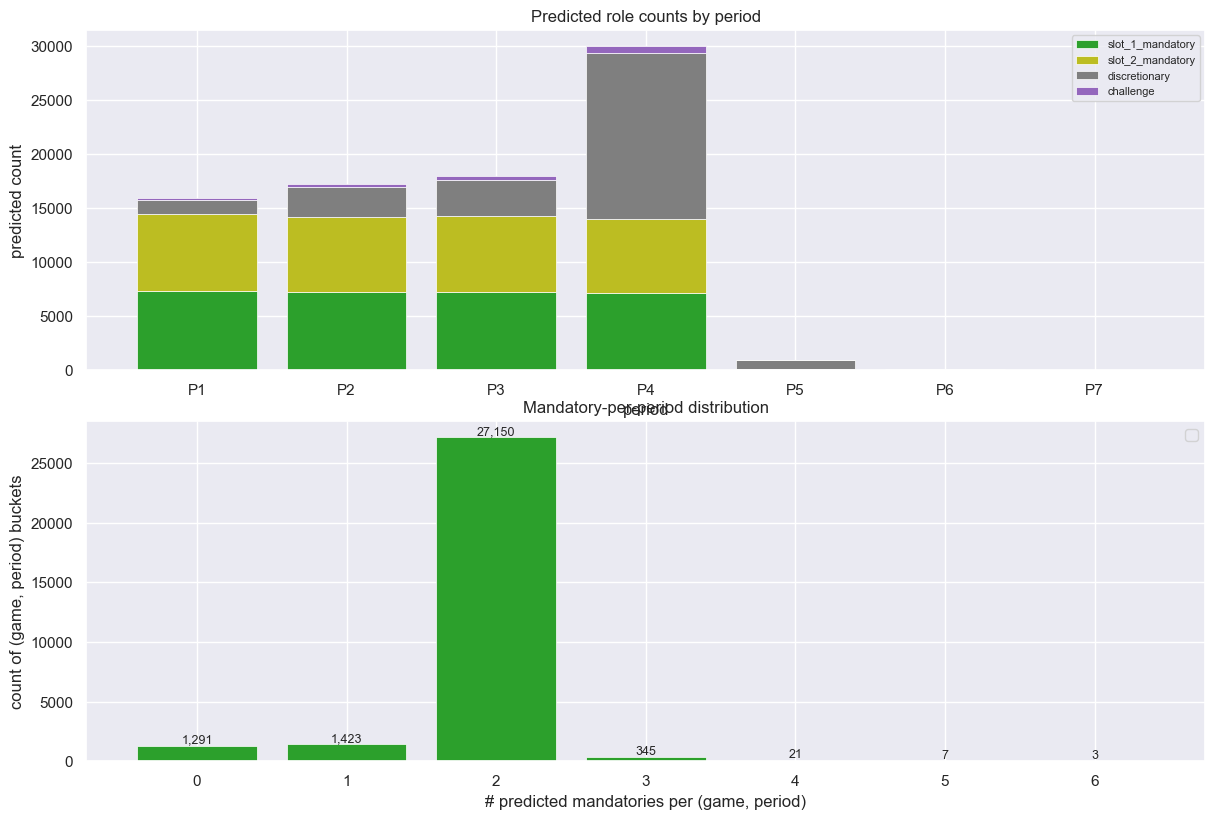

In [15]:
figs["role_counts_per_period"]

In [16]:
# figs["team_mandatory_share"]

# Sandbox

In [17]:
UKS_NP_PD.dtt(
    [
        memo_cdn.cdnnba,
        classified,
    ],
    num_cols=1,
    filter=memo_cdn.f_timeout,
    # filter=f_index,
    show_dims=True,
    # filter=f_nearby,
    # highlight_filter=f_index,
    how="sample",
    n=4,
    seed=0,
)

Calculating f_timeout


game_date 
 gameId 
 orderNumber 
 actionType 
 subType 
 description 
 scoreHome 
 scoreAway 
 pointsTotal 
 possession 
 period 
 game_seconds_elapsed 
 seconds_remaining 
 seconds_elapsed 
 IsPlayoff 
 periodType 
 qualifiers 
 edited 
 isFieldGoal 
 side 
 personIdsFilter 
 teamTricode 
 descriptor 
 jumpBallRecoveredName 
 jumpBallWonPlayerName 
 jumpBallWonPersonId 
 jumpBallLostPlayerName 
 jumpBallLostPersonId 
 officialId 
 turnoverTotal 
 foulPersonalTotal 
 foulTechnicalTotal 
 foulDrawnPlayerName 
 foulDrawnPersonId 
 shotResult 
 assistPlayerNameInitial 
 assistPersonId 
 assistTotal 
 shotActionNumber 
 reboundTotal 
 reboundDefensiveTotal 
 reboundOffensiveTotal 
 blockPlayerName 
 blockPersonId 
 jumpBallRecoverdPersonId 
 stealPlayerName 
 stealPersonId 
 area 
 areaDetail 
 isTargetScoreLastPeriod 
 playerNameI 
 actionNumber 
 clock 
 timeActual 
 teamId 
 personId 
 playerName 
 xLegacy 
 yLegacy 
 x 
 y 
 shotDistance 
 season_type 
 season 
 shot_value 
 points_scored 
 score_margin 
 is_clutch 
 prev_action_type 
 x_court 
 y_court 
 possession_id 
 possession_points 
 possession_outcome 
 timeout_duration_s 
 timeout_role 
 timeout_cause 
 cumTimeoutsPeriod 
 
 
 
 datetime64[ms] 
 int64 
 int64 
 category 
 category 
 str 
 int64 
 int64 
 float64 
 int64 
 int64 
 float64 
 float64 
 float64 
 bool 
 category 
 str 
 datetime64[us, UTC] 
 int64 
 category 
 str 
 category 
 str 
 str 
 str 
 float64 
 str 
 float64 
 float64 
 float64 
 float64 
 float64 
 str 
 float64 
 category 
 str 
 float64 
 float64 
 float64 
 float64 
 float64 
 float64 
 str 
 float64 
 float64 
 str 
 float64 
 category 
 category 
 object 
 category 
 int64 
 str 
 datetime64[us, UTC] 
 float64 
 int64 
 category 
 float64 
 float64 
 float64 
 float64 
 float64 
 str 
 int64 
 float64 
 int64 
 int64 
 bool 
 category 
 float64 
 float64 
 float64 
 float64 
 str 
 float64 
 str 
 str 
 int64 
 
 
 
 
 815427 
 2021-11-27 
 22100287 
 5230000 
 timeout 
 full 
 SAS Timeout 
 70 
 68 
 NaN 
 1610612759 
 4 
 2246.000 
 634.000 
 86.000 
 False 
 REGULAR 
 team, mandatory 
 2021-11-27 03:22:55+00:00 
 0 
 NaN 
 NaN 
 SAS 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 None 
 NaN 
 540 
 PT10M34.00S 
 2021-11-27 03:22:55.600000+00:00 
 1610612759.000 
 0 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 rg 
 2021 
 NaN 
 0 
 2 
 False 
 2pt 
 NaN 
 NaN 
 152.000 
 2.000 
 made_2pt 
 190.000 
 slot_1_mandatory 
 mistagged_discretionary 
 1 
 
 
 2858188 
 2024-10-27 
 22400097 
 6360000 
 timeout 
 full 
 PHI Timeout 
 98 
 97 
 NaN 
 1610612754 
 4 
 2734.000 
 146.000 
 574.000 
 False 
 REGULAR 
 team 
 2024-10-27 21:58:30+00:00 
 0 
 NaN 
 NaN 
 PHI 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 False 
 NaN 
 651 
 PT02M26.00S 
 2024-10-27 21:54:36.500000+00:00 
 1610612755.000 
 0 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 rg 
 2024 
 NaN 
 0 
 1 
 True 
 foul 
 NaN 
 NaN 
 181.000 
 2.000 
 ft_2_of_2 
 203.000 
 discretionary 
 coach_discretionary 
 3 
 
 
 3665364 
 2025-11-12 
 22500211 
 650000 
 timeout 
 full 
 UTA Timeout 
 10 
 20 
 NaN 
 1610612762 
 1 
 252.000 
 468.000 
 252.000 
 False 
 REGULAR 
 team, mandatory 
 2025-11-12 02:17:57+00:00 
 0 
 NaN 
 NaN 
 UTA 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 False 
 NaN 
 65 
 PT07M48.00S 
 2025-11-12 02:17:57.900000+00:00 
 1610612762.000 
 0 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 rg 
 2025 
 NaN 
 0 
 -10 
 False 
 3pt 
 NaN 
 NaN 
 19.000 
 3.000 
 made_3pt 
 217.000 
 slot_1_mandatory 
 coach_absorb 
 1 
 
 
 3763530 
 2025-12-05 
 22500337 
 5860000 
 timeout 
 full 
 NOP Timeout 
 91 
 96 
 NaN 
 1610612740 
 4 
 2314.000 
 56

In [18]:
index = [360]
f_index = np.zeros(len(memo_cdn.cdnnba), dtype=bool)
f_index[index] = True

In [19]:
f_nearby = UKS_NP_PD.get_nearby_rows(
    memo_cdn.cdnnba, f_index, hard_match=["gameId", "period"], soft_match={"seconds_elapsed": (60, "backward")}
)
f_nearby.sum()

np.int64(13)

In [20]:
UKS_NP_PD.dtt(
    [
        memo_cdn.cdnnba,
        classified,
    ],
    num_cols=1,
    # filter=memo_cdn.f_timeout,
    # filter=f_index,
    show_dims=True,
    filter=f_nearby,
    highlight_filter=f_index,
    how="head",
    n=20,
)

,game_date,gameId,orderNumber,actionType,subType,description,scoreHome,scoreAway,pointsTotal,possession,period,game_seconds_elapsed,seconds_remaining,seconds_elapsed,IsPlayoff,periodType,qualifiers,edited,isFieldGoal,side,personIdsFilter,teamTricode,descriptor,jumpBallRecoveredName,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,officialId,turnoverTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,shotResult,assistPlayerNameInitial,assistPersonId,assistTotal,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,blockPlayerName,blockPersonId,jumpBallRecoverdPersonId,stealPlayerName,stealPersonId,area,areaDetail,isTargetScoreLastPeriod,playerNameI,actionNumber,clock,timeActual,teamId,personId,playerName,xLegacy,yLegacy,x,y,shotDistance,season_type,season,shot_value,points_scored,score_margin,is_clutch,prev_action_type,x_court,y_court,possession_id,possession_points,possession_outcome,timeout_duration_s,timeout_role,timeout_cause,cumTimeoutsPeriod
,datetime64[ms],int64,int64,category,category,str,int64,int64,float64,int64,int64,float64,float64,float64,bool,category,str,"datetime64[us, UTC]",int64,category,str,category,str,str,str,float64,str,float64,float64,float64,float64,float64,str,float64,category,str,float64,float64,float64,float64,float64,float64,str,float64,float64,str,float64,category,category,object,category,int64,str,"datetime64[us, UTC]",float64,int64,category,float64,float64,float64,float64,float64,str,int64,float64,int64,int64,bool,category,float64,float64,float64,float64,str,float64,str,str,int64
348,2020-12-23,22000001,3920000,2pt,Hook,MISS J. Wiseman 7' Hook,73,49,NaN,1610612744,3,1603.000,557.000,163.000,False,REGULAR,pointsinthepaint,2020-12-23 01:27:17+00:00,1,right,1630164,GSW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,J. Wiseman,408,PT09M17.00S,2020-12-23 01:27:09.100000+00:00,1610612744.000,1630164,Wiseman,0.000,74.000,86.547,50.069,7.400,rg,2020,2.000,0,24,False,freethrow,0.000,74.000,128.000,0.000,miss,NaN,,,0
349,2020-12-23,22000001,3930000,rebound,defensive,S. Dinwiddie REBOUND (Off:0 Def:5),73,49,NaN,1610612751,3,1609.000,551.000,169.000,False,REGULAR,NaN,2020-12-23 01:27:17+00:00,0,NaN,203915,BKN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,408.000,5.000,5.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,S. Dinwiddie,409,PT09M11.00S,2020-12-23 01:27:15.100000+00:00,1610612751.000,203915,Dinwiddie,NaN,NaN,NaN,NaN,NaN,rg,2020,NaN,0,24,False,2pt,NaN,NaN,129.000,2.000,made_2pt,NaN,,,0
350,2020-12-23,22000001,3940000,foul,personal,J. Toscano-Anderson personal FOUL (2 PF),73,49,NaN,1610612751,3,1615.000,545.000,175.000,False,REGULAR,NaN,2020-12-23 01:27:42+00:00,0,NaN,"1629308, 201599",GSW,NaN,NaN,NaN,NaN,NaN,NaN,202053.000,NaN,2.000,0.000,Jordan,201599.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,J. Toscano-Anderson,410,PT09M05.00S,2020-12-23 01:27:29.300000+00:00,1610612744.000,1629308,Toscano-Anderson,NaN,NaN,NaN,NaN,NaN,rg,2020,NaN,0,24,False,rebound,NaN,NaN,129.000,2.000,made_2pt,NaN,,,0
351,2020-12-23,22000001,3960000,2pt,Layup,J. Harris cutting Layup (10 PTS) (K. Durant 3 AST),75,49,10.000,1610612751,3,1621.000,539.000,181.000,False,REGULAR,pointsinthepaint,2020-12-23 01:27:55+00:00,1,left,"203925, 201142",BKN,cutting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Made,K. Durant,201142.000,3.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,J. Harris,412,PT08M59.00S,2020-12-23 01:27:46.700000+00:00,1610612751.000,203925,Harris,6.000,-5.000,5.076,48.843,0.750,rg,2020,2.000,2,26,False,foul,6.000,-5.000,129.000,2.000,made_2pt,NaN,,,0
352,2020-12-23,22000001,3980000,2pt,Layup,MISS A. Wiggins driving Layup,75,49,NaN,1610612744,3,1632.000,528.000,192.000,False,REGULAR,pointsinthepaint,2020-12-23 01:28:03+00:00,1,right,203952,GSW,driving,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missed,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [21]:
index = [3510580]
f_index = np.zeros(len(memo_cdn.cdnnba), dtype=bool)
f_index[index] = True

In [22]:
f_nearby = UKS_NP_PD.get_nearby_rows(
    memo_cdn.cdnnba, f_index, hard_match=["gameId", "period"], soft_match={"seconds_elapsed": (60, "backward")}
)
f_nearby.sum()

np.int64(20)

In [23]:
UKS_NP_PD.dtt(
    [
        memo_cdn.cdnnba,
        classified,
    ],
    num_cols=1,
    # filter=memo_cdn.f_timeout,
    # filter=f_index,
    show_dims=True,
    filter=f_nearby,
    highlight_filter=f_index,
    how="head",
    n=25,
)

,game_date,gameId,orderNumber,actionType,subType,description,scoreHome,scoreAway,pointsTotal,possession,period,game_seconds_elapsed,seconds_remaining,seconds_elapsed,IsPlayoff,periodType,qualifiers,edited,isFieldGoal,side,personIdsFilter,teamTricode,descriptor,jumpBallRecoveredName,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,officialId,turnoverTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,shotResult,assistPlayerNameInitial,assistPersonId,assistTotal,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,blockPlayerName,blockPersonId,jumpBallRecoverdPersonId,stealPlayerName,stealPersonId,area,areaDetail,isTargetScoreLastPeriod,playerNameI,actionNumber,clock,timeActual,teamId,personId,playerName,xLegacy,yLegacy,x,y,shotDistance,season_type,season,shot_value,points_scored,score_margin,is_clutch,prev_action_type,x_court,y_court,possession_id,possession_points,possession_outcome,timeout_duration_s,timeout_role,timeout_cause,cumTimeoutsPeriod
,datetime64[ms],int64,int64,category,category,str,int64,int64,float64,int64,int64,float64,float64,float64,bool,category,str,"datetime64[us, UTC]",int64,category,str,category,str,str,str,float64,str,float64,float64,float64,float64,float64,str,float64,category,str,float64,float64,float64,float64,float64,float64,str,float64,float64,str,float64,category,category,object,category,int64,str,"datetime64[us, UTC]",float64,int64,category,float64,float64,float64,float64,float64,str,int64,float64,int64,int64,bool,category,float64,float64,float64,float64,str,float64,str,str,int64
3510565,2025-04-12,22401178,5650000,violation,kicked ball,A. Lawson kicked ball VIOLATION,106,81,NaN,1610612742,4,2429.000,451.000,269.000,False,REGULAR,NaN,2025-04-12 02:25:28+00:00,0,NaN,1630639,TOR,NaN,NaN,NaN,NaN,NaN,NaN,1628954.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,A. Lawson,570,PT07M31.00S,2025-04-12 02:25:24+00:00,1610612761.000,1630639,Lawson,NaN,NaN,NaN,NaN,NaN,rg,2024,NaN,0,25,False,2pt,NaN,NaN,178.000,2.000,ft_2_of_2,NaN,,,1
3510566,2025-04-12,22401178,5660000,substitution,out,SUB out: N. Marshall,106,81,NaN,1610612742,4,2429.000,451.000,269.000,False,REGULAR,NaN,2025-04-12 02:25:40+00:00,0,NaN,1630230,DAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,N. Marshall,571,PT07M31.00S,2025-04-12 02:25:28.800000+00:00,1610612742.000,1630230,Marshall,NaN,NaN,NaN,NaN,NaN,rg,2024,NaN,0,25,False,violation,NaN,NaN,178.000,2.000,ft_2_of_2,NaN,,,1
3510567,2025-04-12,22401178,5670000,substitution,in,SUB in: J. Hardy,106,81,NaN,1610612742,4,2429.000,451.000,269.000,False,REGULAR,NaN,2025-04-12 02:25:40+00:00,0,NaN,1630702,DAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,J. Hardy,572,PT07M31.00S,2025-04-12 02:25:28.800000+00:00,1610612742.000,1630702,Hardy,NaN,NaN,NaN,NaN,NaN,rg,2024,NaN,0,25,False,substitution,NaN,NaN,178.000,2.000,ft_2_of_2,NaN,,,1
3510568,2025-04-12,22401178,5680000,2pt,Jump Shot,MISS C. Martin 8' turnaround fadeaway Shot,106,81,NaN,1610612742,4,2434.000,446.000,274.000,False,REGULAR,pointsinthepaint,2025-04-12 02:26:26+00:00,1,right,1628997,DAL,turnaround fadeaway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In The Paint (Non-RA),8-16 Left,False,C. Martin,573,PT07M26.00S,2025-04-12 02:25:47.500000+00:00,1610612742.000,1628997,Martin,-71.000,49.000,89.175,35.784,8.650,rg,2024,2.000,0,25,False,substitution,-71.000,49.000,178.000,2.000,ft_2_of_2,NaN,,,1
3510569,2025-04-12,22401178,5690000,rebound,offensive,D. Gafford REBOUND (Off:1 Def:4),106,81,NaN,1610612742,4,2436.000,444.000,276.000,False,REGULAR,NaN,2025-04-12 02:25:50+00:00,0,NaN,1629655,DAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,573.000,5.000,4.000,1.000,NaN,NaN,NaN,NaN,NaN,In The Paint (Non-RA),8-16 Left,

In [24]:
UKS_NP_PD.dtt([classified["timeout_role"].value_counts(), classified["timeout_cause"].value_counts()], n=-1)

,timeout_role,count
,str,uint32
0,slot_1_mandatory,28970
1,slot_2_mandatory,27925
2,,4086589
3,discretionary,23747
4,challenge,1555
,timeout_cause,count
,str,uint32
0,,4086589
1,tv_mandatory,13172


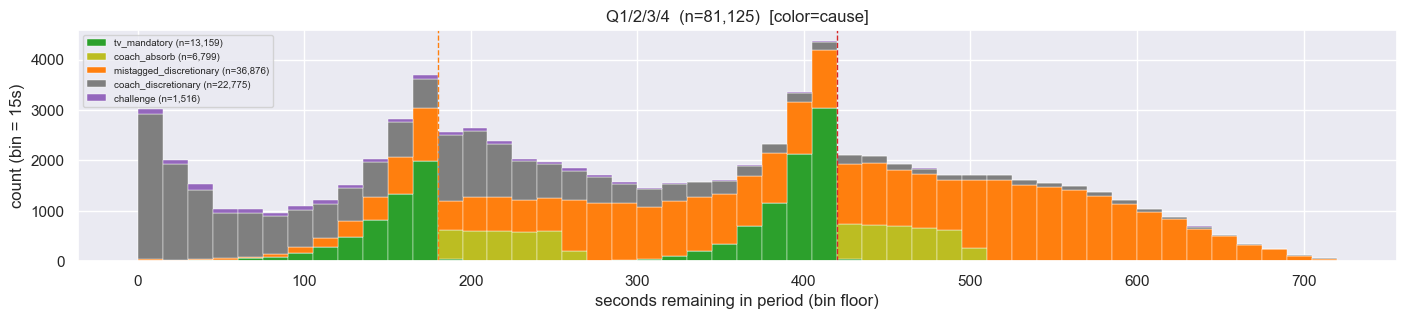

In [25]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, color_by="cause", combine_periods=True)
fig

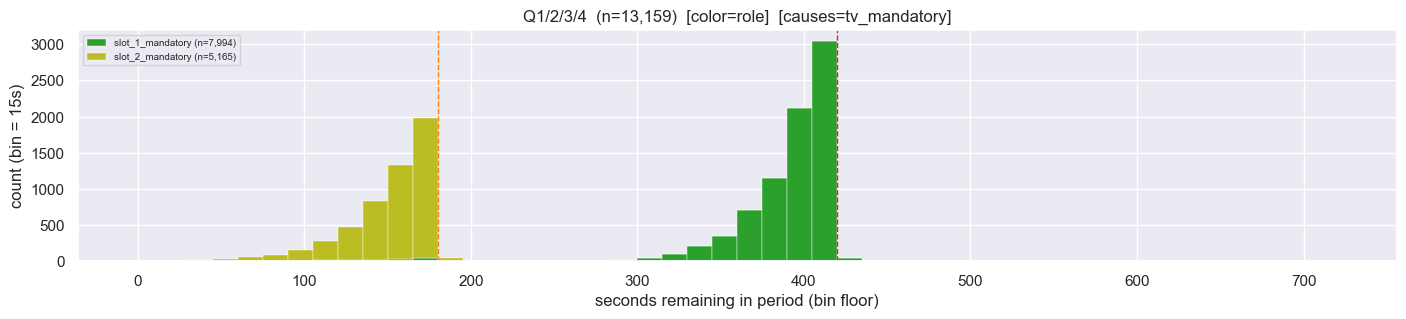

In [26]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("tv_mandatory",), combine_periods=True)
fig

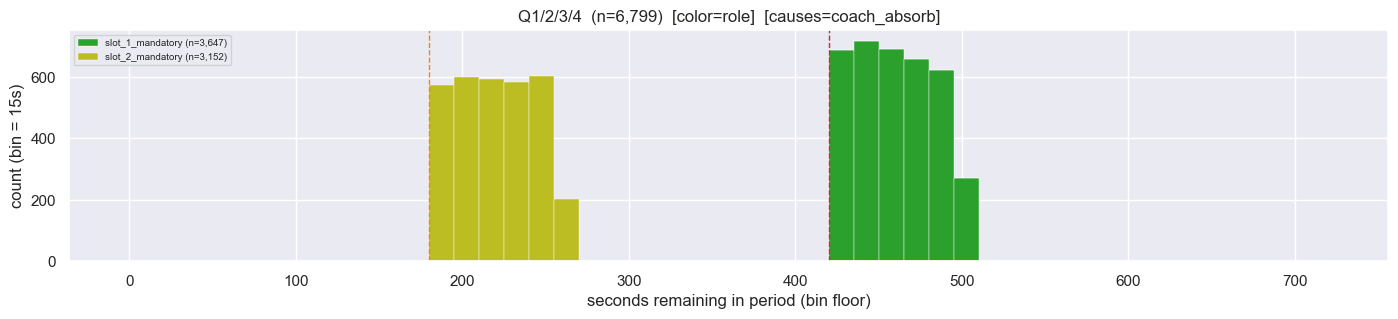

In [27]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("coach_absorb",), combine_periods=True)
fig

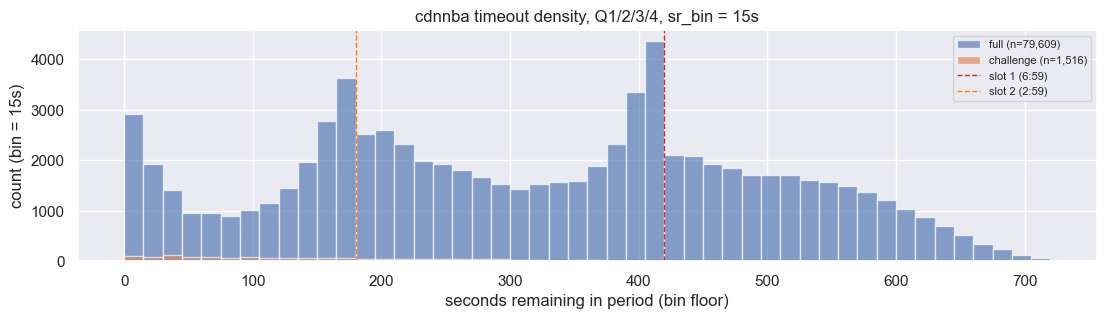

In [28]:
fig_vanilla

In [29]:
classified["timeout_cause"].value_counts()

timeout_cause,count
str,u32
"""coach_absorb""",6805
"""""",4086589
"""mistagged_discretionary""",36918
"""tv_mandatory""",13172
"""challenge""",1555
"""coach_discretionary""",23747


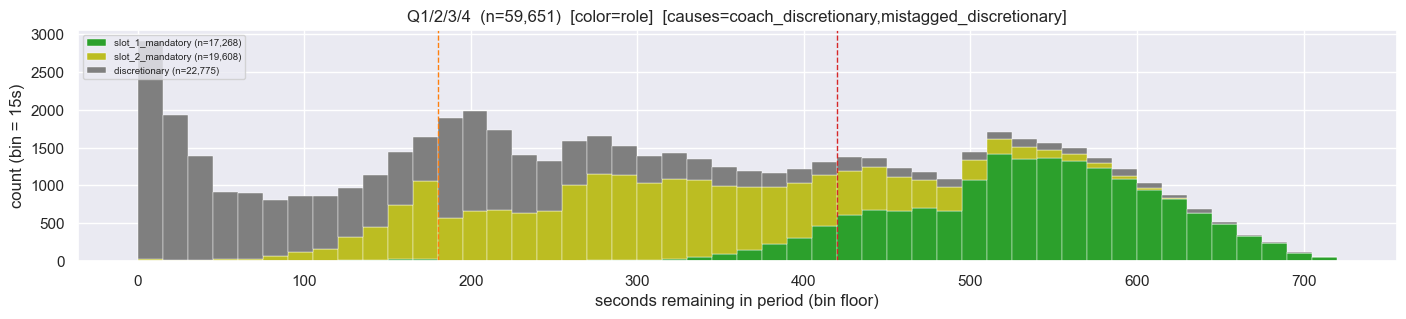

In [30]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(
    classified,
    causes=(
        "coach_discretionary",
        "mistagged_discretionary",
    ),
    combine_periods=True,
)
fig

In [31]:
memo_cdn.cdnnba["subType"].filter(memo_cdn.f_timeout).value_counts()

subType,count
cat,u32
"""challenge""",1555
"""full""",80642
